In [ ]:
import cv2
import numpy as np

def preprocess_for_ocr(image_path, output_path="cleaned_image.png"):
    # read image
    img = cv2.imread(image_path)

    if img is None:
        print("Error: Unable to load image.")
        return

    # convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # reduce noise using bilateral filter (keeps edges sharp)
    denoised = cv2.bilateralFilter(gray, 9, 75, 75)

    # detect background illumination using Gaussian blur
    background = cv2.GaussianBlur(denoised, (35, 35), 0)

    # subtract background to enhance text
    enhanced = cv2.divide(denoised, background, scale=255)

    # apply adaptive thresholding
    thresh = cv2.adaptiveThreshold(
        enhanced,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        31,
        15
    )

    # small morphological operation to clean tiny noise
    kernel = np.ones((2, 2), np.uint8)
    cleaned = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

    # save final image
    cv2.imwrite(output_path, cleaned)

    print("Preprocessing completed. Saved as:", output_path)


if __name__ == "__main__":
    image_path = "input.jpg"   # change to your image path
    preprocess_for_ocr(image_path)

Error: Unable to load image.


Preprocessing completed. Saved as: cleaned_image.png


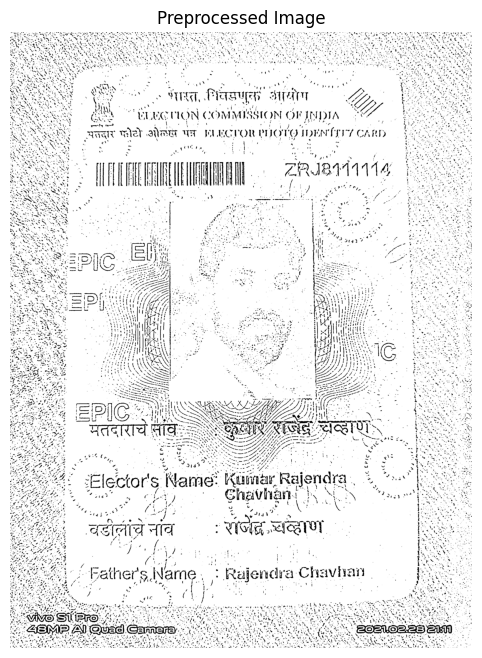

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def preprocess_for_ocr(image_path, output_path="cleaned_image.png"):
    # read image
    img = cv2.imread(image_path)

    if img is None:
        print("Error: Unable to load image.")
        return

    # convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # reduce noise using bilateral filter (keeps edges sharp)
    denoised = cv2.bilateralFilter(gray, 9, 75, 75)

    # detect background illumination using Gaussian blur
    background = cv2.GaussianBlur(denoised, (35, 35), 0)

    # subtract background to enhance text
    enhanced = cv2.divide(denoised, background, scale=255)

    # apply adaptive thresholding
    thresh = cv2.adaptiveThreshold(
        enhanced,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        31,
        15
    )

    # small morphological operation to clean tiny noise
    kernel = np.ones((2, 2), np.uint8)
    cleaned = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

    # save final image
    cv2.imwrite(output_path, cleaned)

    print("Preprocessing completed. Saved as:", output_path)

    # Display the preprocessed image
    plt.figure(figsize=(10, 8))
    plt.imshow(cleaned, cmap='gray')
    plt.title('Preprocessed Image')
    plt.axis('off')
    plt.show()


if __name__ == "__main__":
    image_path = "6.jpg"   # changed to '6.jpg'
    preprocess_for_ocr(image_path)

 To write a python script to detect and remove noisy backgrounds before ocr preprocessing